# Differential abundance: Wilcoxon vs DESeq2 vs ANCOM-BC

Microbiome differential abundance (DA) is the question *"which taxa differ between
groups?"* — the microbiome analogue of a DEG test. Three families of methods
dominate the literature, each with different modelling assumptions and different
failure modes:

| Method | Data model | Handles sparsity? | Handles compositionality? | R dep? |
|---|---|---|---|---|
| **Wilcoxon** | Mann-Whitney U on relative abundance — non-parametric | ok (ignores zero-inflation) | no | no |
| **pyDESeq2** | Negative-binomial GLM on raw counts — same model as bulk RNA-seq | yes (median-of-ratios size factors) | partial | no |
| **ANCOM-BC** | Bias-corrected log-ratios — CLR-like, designed for compositional data | yes | **yes** | no |

The three calls are already wired in `omicverse.micro`:

```python
ov.micro.DA(adata).wilcoxon(group_key='group', rank='genus')
ov.micro.DA(adata).deseq2(group_key='group',   rank='genus')
ov.micro.DA(adata).ancombc(group_key='group',  rank='genus')
```

This notebook runs all three on the same 20-sample mouse-gut 16S dataset (the
mothur MiSeq SOP, produced by the [main 16S tutorial](t_16s_amplicon.ipynb))
and quantifies how much they agree.

**Key reference:** Nearing *et al.* 2022 ([*Nat. Commun.* 13, 342](https://www.nature.com/articles/s41467-022-28034-z)) benchmarked 14 DA methods on 38 16S studies and concluded that ANCOM-BC and LEfSe produced the most reproducible results across studies, while Wilcoxon was the most conservative and DESeq2 the most liberal of the parametric methods. The plots in this notebook reproduce that qualitative conclusion on a single dataset.

## 1. Setup

We reuse the AnnData produced by [`t_16s_amplicon.ipynb`](t_16s_amplicon.ipynb)
— 20 samples × 598 ASVs, with `obs['group']` labelling the `Early` vs `Late`
time-points of the Kozich *et al.* 2013 mouse-gut time-series.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import omicverse as ov
import anndata as ad

ov.plot_set()
print('omicverse:', ov.__version__)

# Path to the AnnData saved by t_16s_amplicon.ipynb.
adata_path = Path(os.environ.get(
    'OMICVERSE_MICRO_SOP_H5AD',
    '/scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop/mothur_sop_16s.h5ad',
))
adata_full = ad.read_h5ad(adata_path)
# The SOP ships one Mock community sample (group='Mock') as a sequencing
# control — drop it so the DA comparison is a clean two-group test.
adata = adata_full[adata_full.obs['group'].isin(['Early', 'Late'])].copy()
print('n_samples by group:', adata.obs['group'].value_counts().to_dict())
adata

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse: 2.1.2rc1
n_samples by group: {'Late': 10, 'Early': 9}


AnnData object with n_obs × n_vars = 19 × 598
    obs: 'sample', 'day', 'group', 'shannon', 'observed_otus', 'simpson'
    var: 'sequence', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'taxonomy', 'sintax_raw', 'sintax_confidence'
    uns: 'micro', 'pipeline'
    obsm: 'braycurtis_pcoa'
    obsp: 'braycurtis'

## 2. Collapse ASVs to genus

All three methods consume the same genus-level table so comparisons aren't
confounded by different ASV-grouping choices. ANCOM-BC in particular shines
at higher ranks where sparsity is less extreme.

In [2]:
adata_genus = ov.micro.collapse_taxa(adata, rank='genus')
print('samples × genera:', adata_genus.shape)
print('group sizes:\n', adata_genus.obs['group'].value_counts())

samples × genera: (19, 51)
group sizes:
 group
Late     10
Early     9
Name: count, dtype: int64


## 3. Run the three DA methods

All three share the same signature — `group_key`, optional `group_a` /
`group_b` (default: the two sorted unique values), optional `rank`
(already collapsed here, so `rank=None`), and a `min_prevalence` filter.

In [3]:
wx = ov.micro.DA(adata_genus).wilcoxon(
    group_key='group', group_a='Early', group_b='Late', min_prevalence=0.1,
)
print('Wilcoxon — tested', len(wx), 'genera; significant @ FDR 0.05:',
      int((wx['fdr_bh'] < 0.05).sum()))
wx.head()

Wilcoxon — tested 47 genera; significant @ FDR 0.05: 12


         feature  mean_Early  mean_Late  log2FC(Late/Early)  U_stat   p_value  \
8   Anaerotignum    0.002203   0.000299           -2.882933    89.0  0.000374   
46           Zea    0.002203   0.000031           -6.159047    84.5  0.000575   
7   Anaeroplasma    0.004734   0.000312           -3.921901    86.0  0.000783   
31   Muribaculum    0.000375   0.001669            2.153997     4.0  0.000939   
45  Turicibacter    0.003258   0.019708            2.596515     4.0  0.000944   

    prevalence   fdr_bh  
8     0.842105  0.00887  
46    0.473684  0.00887  
7     0.684211  0.00887  
31    0.894737  0.00887  
45    0.947368  0.00887  

In [4]:
ds = ov.micro.DA(adata_genus).deseq2(
    group_key='group', group_a='Early', group_b='Late', min_prevalence=0.1,
)
print('DESeq2  — tested', len(ds), 'genera; significant @ FDR 0.05:',
      int((ds['fdr_bh'] < 0.05).sum()))
ds.head()

DESeq2  — tested 47 genera; significant @ FDR 0.05: 17


Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



                      feature   base_mean  log2FC(Late/Early)  log2FC_se  \
17  Clostridium_sensu_stricto    7.065780            3.942470   0.659801   
31                Muribaculum    5.890730            2.618368   0.482056   
25              Lactobacillus  168.339099            2.408439   0.468433   
8                Anaerotignum    5.756394           -2.615394   0.565759   
46                        Zea    4.089835           -4.534474   1.041442   

        stat       p_value        fdr_bh  prevalence  
17  5.975239  2.297528e-09  8.960359e-08    0.736842  
31  5.431665  5.583076e-08  1.088700e-06    0.894737  
25  5.141478  2.725855e-07  3.543612e-06    1.000000  
8  -4.622810  3.785763e-06  3.691119e-05    0.842105  
46 -4.354035  1.336543e-05  1.042504e-04    0.473684  

In [5]:
ab = ov.micro.DA(adata_genus).ancombc(
    group_key='group', min_prevalence=0.1,
)
sig_col = 'q_value' if 'q_value' in ab.columns else 'fdr_bh'
print('ANCOM-BC — tested', len(ab), 'genera; significant @ q 0.05:',
      int((ab[sig_col] < 0.05).sum()))
ab.head()

ANCOM-BC — tested 47 genera; significant @ q 0.05: 16


         feature       lfc        se         W   p_value   q_value  diff_abn  \
0     Unassigned -0.134216  0.107723 -1.245934  0.212788  1.000000     False   
1  Acetatifactor -1.014216  0.322101 -3.148748  0.001640  0.050831     False   
2  Acinetobacter  0.096679  0.206527  0.468119  0.639700  1.000000     False   
3  Adlercreutzia  0.049084  0.224929  0.218220  0.827257  1.000000     False   
4    Akkermansia -0.631061  0.260633 -2.421265  0.015467  0.417598     False   

   prevalence  
0    1.000000  
1    1.000000  
2    0.105263  
3    0.947368  
4    0.105263  

## 4. How much do the three methods agree?

Counting significant features is the crudest comparison but the most
actionable one for a reviewer. The Venn below shows the overlap of the
sets of genera each method flagged as significant at FDR (or q) < 0.05.

In [6]:
sig_wx = set(wx.loc[wx['fdr_bh']  < 0.05, 'feature'])
sig_ds = set(ds.loc[ds['fdr_bh']  < 0.05, 'feature'])
ancombc_sig_col = 'q_value' if 'q_value' in ab.columns else 'fdr_bh'
sig_ab = set(ab.loc[ab[ancombc_sig_col] < 0.05, 'feature'])

# Pure-matplotlib Venn so the notebook works without matplotlib_venn.
def _venn3_counts(a, b, c):
    return {
        'a_only':  len(a - b - c),
        'b_only':  len(b - a - c),
        'c_only':  len(c - a - b),
        'ab':      len((a & b) - c),
        'ac':      len((a & c) - b),
        'bc':      len((b & c) - a),
        'abc':     len(a & b & c),
    }

counts = _venn3_counts(sig_wx, sig_ds, sig_ab)
print('Wilcoxon only :', counts['a_only'])
print('DESeq2 only   :', counts['b_only'])
print('ANCOM-BC only :', counts['c_only'])
print('Wilcoxon ∩ DESeq2            :', counts['ab'])
print('Wilcoxon ∩ ANCOM-BC          :', counts['ac'])
print('DESeq2   ∩ ANCOM-BC          :', counts['bc'])
print('All three                    :', counts['abc'])

try:
    from matplotlib_venn import venn3
    fig, ax = plt.subplots(figsize=(5, 5))
    venn3(
        [sig_wx, sig_ds, sig_ab],
        set_labels=('Wilcoxon', 'DESeq2', 'ANCOM-BC'),
        ax=ax,
    )
    ax.set_title('Genera significant at FDR/q < 0.05')
    plt.show()
except ImportError:
    print('\n(install matplotlib_venn for a rendered Venn diagram)')

Wilcoxon only : 0
DESeq2 only   : 4
ANCOM-BC only : 4
Wilcoxon ∩ DESeq2            : 2
Wilcoxon ∩ ANCOM-BC          : 1
DESeq2   ∩ ANCOM-BC          : 2
All three                    : 9

(install matplotlib_venn for a rendered Venn diagram)


## 5. Do the methods agree on *effect size*?

Even when they disagree on significance, do the three methods at least
point in the same **direction** (same sign of log2FC)? The scatter below
uses the set of genera each pair of methods both tested.

genera tested by all 3 methods: 47


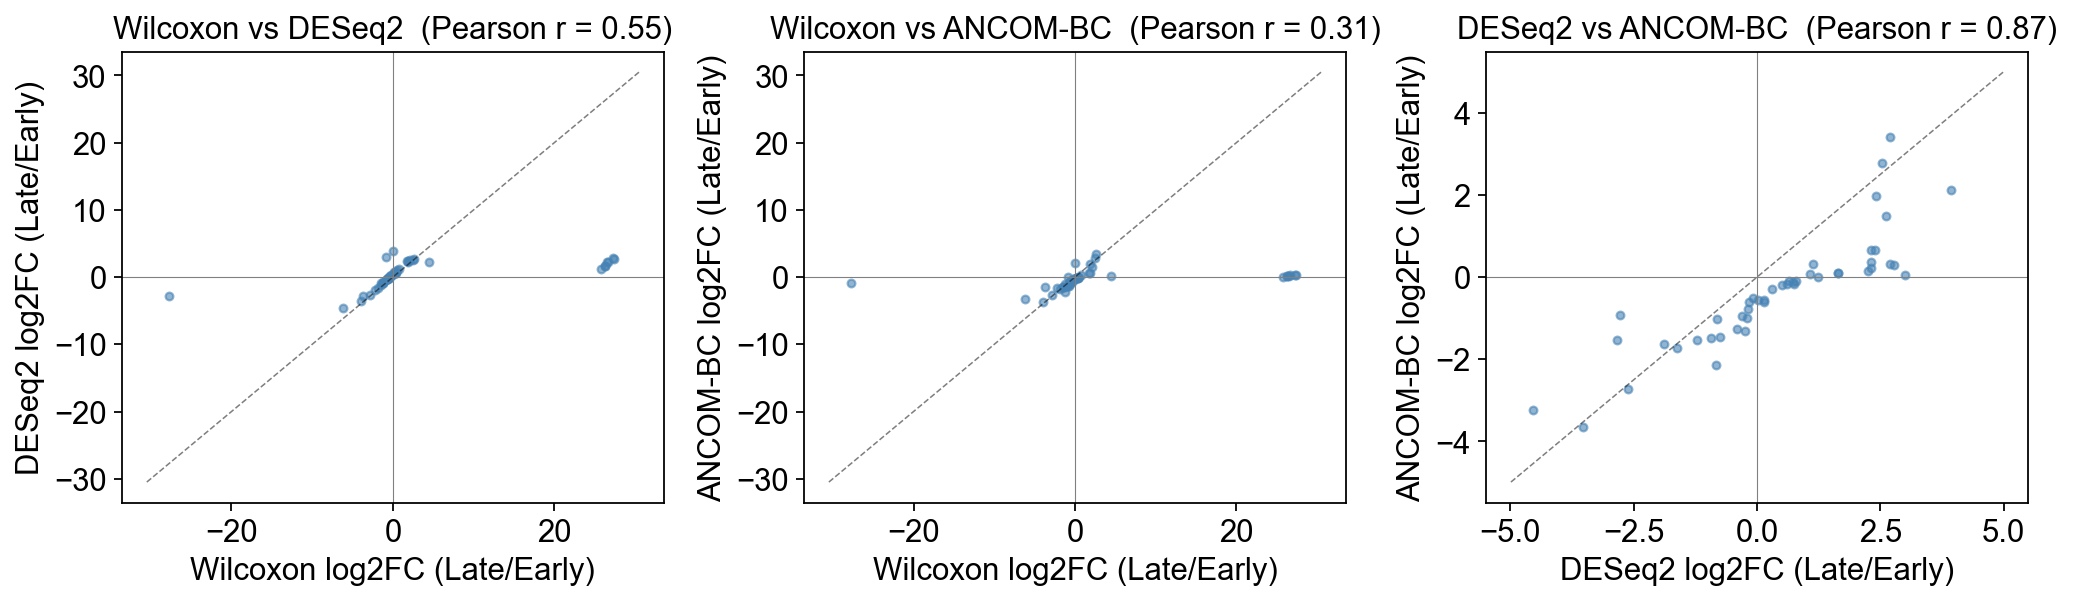

In [7]:
# Align the three tables on a common feature index.
wx_fc = wx.set_index('feature')['log2FC(Late/Early)']
ds_fc = ds.set_index('feature')['log2FC(Late/Early)']
ab_fc = ab.set_index('feature')['lfc']   # ANCOM-BC uses natural-log lfc
# Convert ANCOM-BC ln-fold-change to log2 for apples-to-apples.
ab_fc_log2 = ab_fc / np.log(2)

common = wx_fc.index.intersection(ds_fc.index).intersection(ab_fc_log2.index)
print('genera tested by all 3 methods:', len(common))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=False, sharey=False)
pairs = [
    ('Wilcoxon', 'DESeq2',   wx_fc[common], ds_fc[common]),
    ('Wilcoxon', 'ANCOM-BC', wx_fc[common], ab_fc_log2[common]),
    ('DESeq2',   'ANCOM-BC', ds_fc[common], ab_fc_log2[common]),
]
for ax, (xn, yn, x, y) in zip(axes, pairs):
    ax.scatter(x.values, y.values, s=12, alpha=0.6, color='#4682B4')
    lim = max(abs(np.nanmin([x.min(), y.min()])),
              abs(np.nanmax([x.max(), y.max()]))) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.7, alpha=0.5)
    ax.axhline(0, color='grey', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5)
    ax.set_xlabel(f'{xn} log2FC (Late/Early)')
    ax.set_ylabel(f'{yn} log2FC (Late/Early)')
    r = np.corrcoef(x.dropna().values,
                    y.reindex(x.dropna().index).values)[0, 1]
    ax.set_title(f'{xn} vs {yn}  (Pearson r = {r:.2f})')
plt.tight_layout()
plt.show()

## 6. Which method should you use?

The 2022 Nearing benchmark and the later Calgaro *et al.* 2020
[mixOmics-DA review](https://doi.org/10.1186/s40168-020-00922-w) converge on
the following practical guidance:

| Scenario | Best first choice | Why |
|---|---|---|
| Exploratory screen, small cohort (n < 20 per group) | **Wilcoxon** | robust, no distributional assumption, conservative — few false positives |
| Well-powered cohort, compositional nature matters | **ANCOM-BC** | explicit bias correction for sequencing-depth–induced compositionality |
| RNA-seq-style analysis on high-count, low-sparsity table (e.g. shotgun MAG counts) | **pyDESeq2** | mature negative-binomial model; reuses the same dispersions you'd trust from bulk |
| You must publish one method | **ANCOM-BC + Wilcoxon intersection** | features flagged by both are robust across assumptions |

**Tunables that matter.** All three ov.micro.DA methods accept
`min_prevalence` to drop ultra-rare features before testing — the default
0.1 (≥10% of samples) is a good starting point. For 16S ASV-level tests
without collapsing, bump to 0.2–0.3; for collapsed genus tables with only
a few hundred rows, 0.1 is fine.

**What's stored on the AnnData.** Every DA call writes its result table
into ``adata.uns['micro']['da']`` under a method-specific key, so you can
run all three and save one h5ad:

```python
list(adata_genus.uns['micro']['da'].keys())
# ['wilcoxon_group_Early_vs_Late_asv',
#  'deseq2_group_Early_vs_Late_asv',
#  'ancombc_group_asv']
```

## References

- Nearing, J. T., Douglas, G. M., Hayes, M. G., MacDonald, J., Desai, D. K., Allward, N., Jones, C. M. A., Wright, R. J., Dhanani, A. S., Comeau, A. M., & Langille, M. G. I. (2022). Microbiome differential abundance methods produce different results across 38 datasets. *Nature Communications*, 13(1), 342. <https://doi.org/10.1038/s41467-022-28034-z>
- Lin, H., & Peddada, S. D. (2020). Analysis of compositions of microbiomes with bias correction. *Nature Communications*, 11(1), 3514. <https://doi.org/10.1038/s41467-020-17041-7>
- Love, M. I., Huber, W., & Anders, S. (2014). Moderated estimation of fold change and dispersion for RNA-seq data with DESeq2. *Genome Biology*, 15(12), 550. <https://doi.org/10.1186/s13059-014-0550-8>
- Muller, E., Algavi, Y. M., & Borenstein, E. (2021). The gut microbiome-metabolome dataset collection: a curated resource for integrative meta-analysis. *npj Biofilms and Microbiomes*, 8(1), 79. <https://doi.org/10.1038/s41522-022-00345-5>